Author : Nasr SLIMANI

# Gaussian Process Regression for Financial Time-Series Forecasting


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL


## 2. Parameters

In [3]:
ticker = "NVDA"
start_date = "2023-01-01"
end_date = "2026-01-01"
seq_length = 10
test_size = 0.30
length_scale = 1.0
alpha = 1e-6
seasonal_period = 5


## 3. Data Loading

In [4]:
def load_stock_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )

    if df.empty:
        raise ValueError(f"No data downloaded for ticker {ticker}.")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}. Found columns: {df.columns.tolist()}"
        )

    for col in required_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Close"]).copy()
    return df


df = load_stock_data(ticker, start_date, end_date)
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2023-01-03,14.300682,14.315,14.996,14.096,14.851,401277000
2023-01-04,14.734250,14.749,14.853,14.241,14.567,431324000
2023-01-05,14.250735,14.265,14.564,14.148,14.491,389168000
2023-01-06,14.844140,14.859,15.010,14.034,14.474,405044000
2023-01-09,15.612371,15.628,16.056,15.141,15.284,504231000


## 4. Data Preparation

In [5]:
def compute_log_returns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    df = df.dropna(subset=["log_return"])
    return df


df = compute_log_returns(df)
df[["Close", "log_return"]].head()

Price,Close,log_return
Date,,
2023-01-04,14.749,0.029867
2023-01-05,14.265,-0.033366
2023-01-06,14.859,0.040797
2023-01-09,15.628,0.050458
2023-01-10,15.909,0.017821


## 5. Dataset Overview

In [6]:
print(df.info())
print("Missing values:")
print(df.isnull().sum())

df[["Close", "log_return"]].describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 751 entries, 2023-01-04 to 2025-12-31
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Adj Close   751 non-null    float64
 1   Close       751 non-null    float64
 2   High        751 non-null    float64
 3   Low         751 non-null    float64
 4   Open        751 non-null    float64
 5   Volume      751 non-null    int64  
 6   log_return  751 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 46.9 KB
None
Missing values:
Price
Adj Close     0
Close         0
High          0
Low           0
Open          0
Volume        0
log_return    0
dtype: int64


Price,Close,log_return
count,751.000000,751.000000
mean,99.568077,0.003418
std,53.814612,0.031253
min,14.265000,-0.185946
25%,45.715000,-0.013704
50%,108.379997,0.003662
75%,139.209999,0.021337
max,207.039993,0.218088


## 6. Time-Series Plot

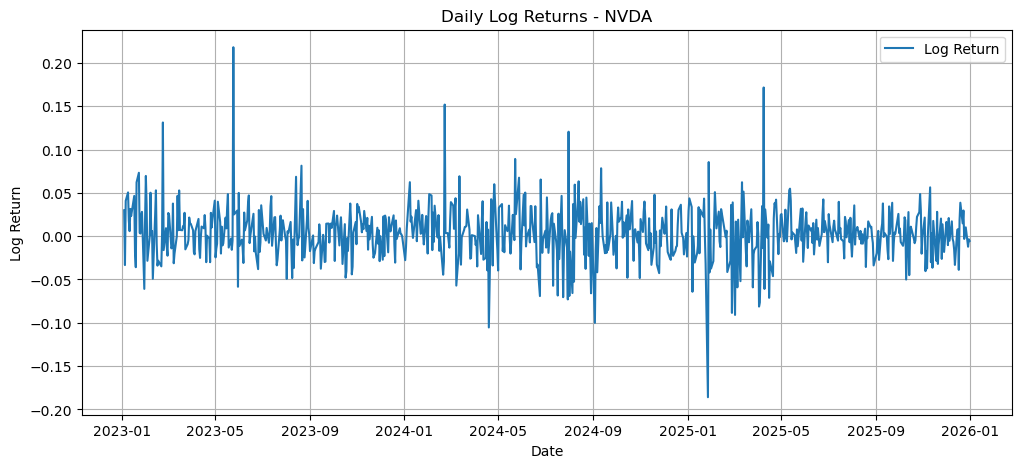

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["log_return"], label="Log Return")
plt.title(f"Daily Log Returns - {ticker}")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.legend()
plt.show()

## 7. Stationarity Test (ADF)

In [8]:
adf_result = adfuller(df["log_return"].dropna())

adf_table = pd.DataFrame({
    "Metric": ["ADF Statistic", "p-value", "Used Lags", "Number of Observations"],
    "Value": [adf_result[0], adf_result[1], adf_result[2], adf_result[3]]
})

critical_values = pd.DataFrame({
    "Critical Value": list(adf_result[4].keys()),
    "Value": list(adf_result[4].values())
})

display(adf_table)
display(critical_values)
print("Conclusion:", "Stationary" if adf_result[1] < 0.05 else "Non-stationary")

,Metric,Value
0,ADF Statistic,-1.703404e+01
1,p-value,8.285943e-30
2,Used Lags,2.000000e+00
3,Number of Observations,7.480000e+02


,Critical Value,Value
0,1%,-3.439123
1,5%,-2.865412
2,10%,-2.568832


Conclusion: Stationary


## 8. ACF / PACF - Log Returns

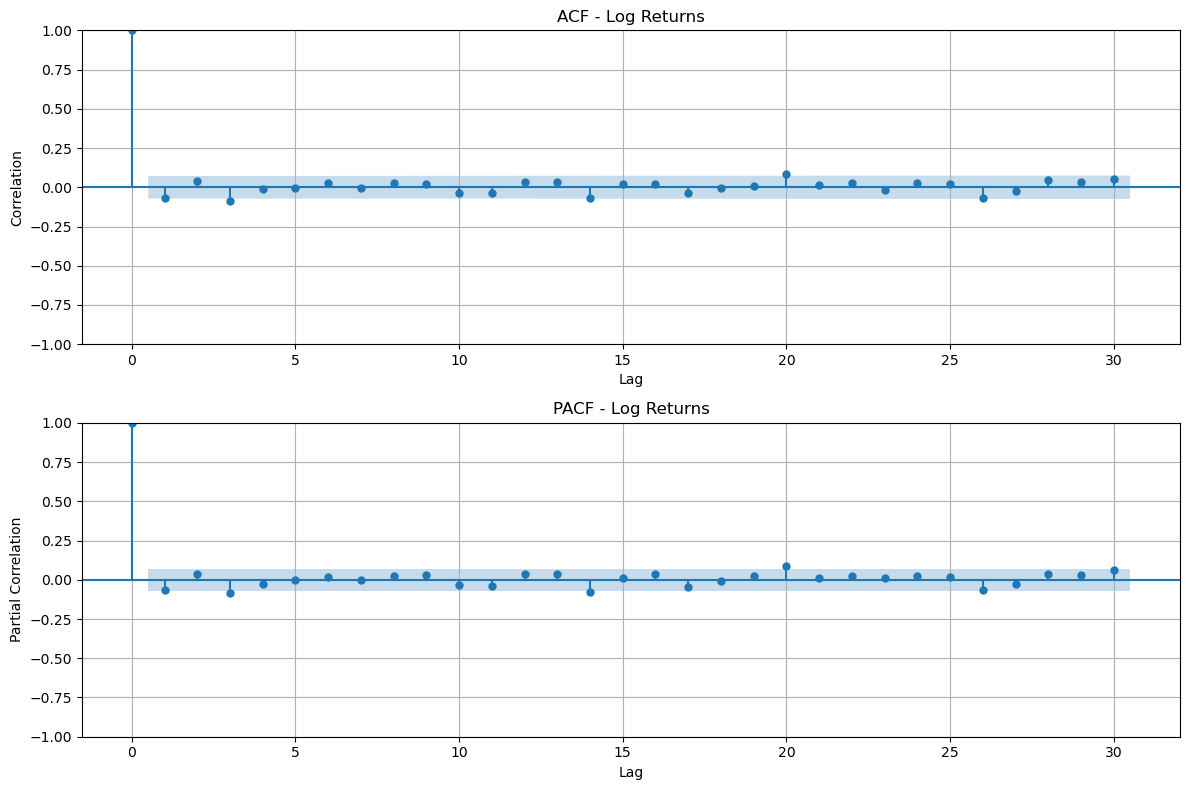

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df["log_return"].dropna(), lags=30, zero=True, ax=axes[0])
axes[0].set_title("ACF - Log Returns")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Correlation")
axes[0].grid(True)

plot_pacf(df["log_return"].dropna(), lags=30, zero=True, ax=axes[1], method="ywm")
axes[1].set_title("PACF - Log Returns")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Partial Correlation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 9. ACF / PACF - Squared Log Returns

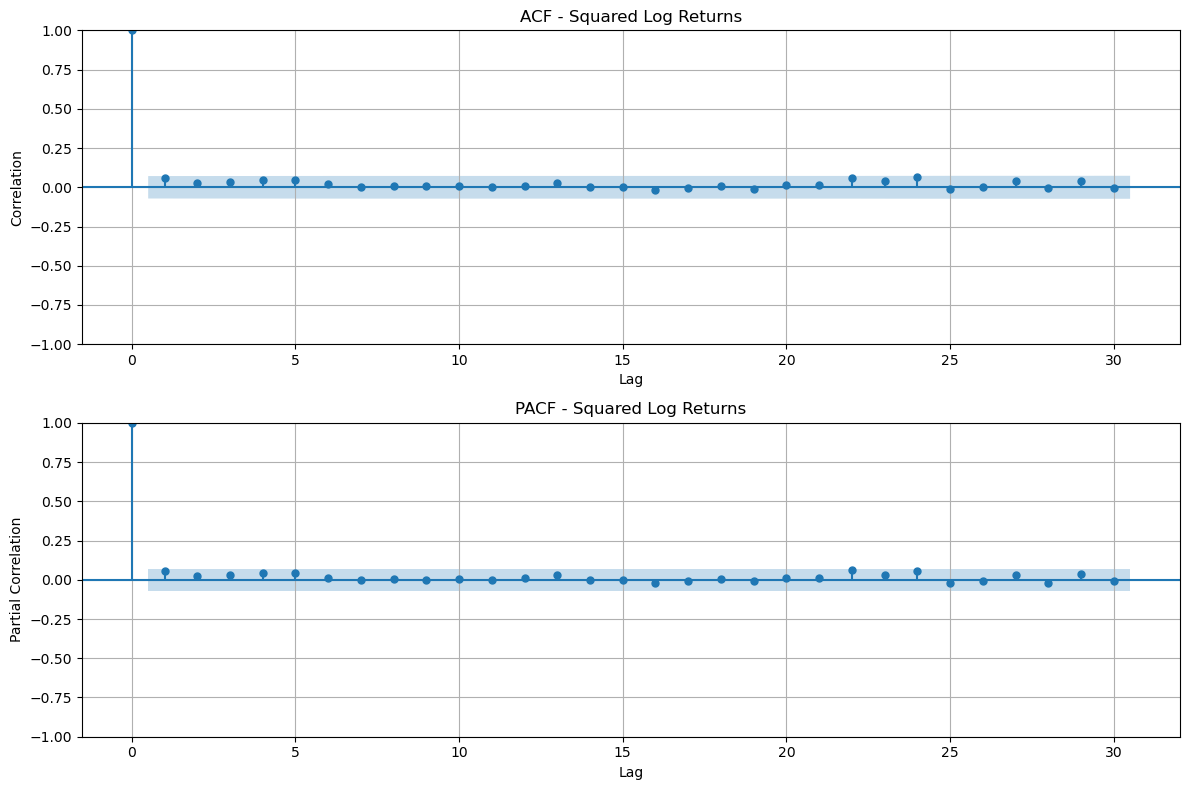

In [10]:
squared_log_returns = df["log_return"] ** 2

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(squared_log_returns.dropna(), lags=30, zero=True, ax=axes[0])
axes[0].set_title("ACF - Squared Log Returns")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Correlation")
axes[0].grid(True)

plot_pacf(squared_log_returns.dropna(), lags=30, zero=True, ax=axes[1], method="ywm")
axes[1].set_title("PACF - Squared Log Returns")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Partial Correlation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 10. Sequential Feature Construction

In [11]:
def create_lagged_sequences(series: np.ndarray, dates: pd.Index, seq_length: int):
    X, y, target_dates = [], [], []

    for i in range(len(series) - seq_length):
        X.append(series[i:i + seq_length])
        y.append(series[i + seq_length])
        target_dates.append(dates[i + seq_length])

    return np.array(X), np.array(y), np.array(target_dates)


log_returns = df["log_return"].values
dates = df.index
X, y, target_dates = create_lagged_sequences(log_returns, dates, seq_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (741, 10)
y shape: (741,)


## 11. Chronological Train/Test Split

In [12]:
def chronological_split(X, y, dates, test_size: float = 0.30):
    split_idx = int(len(X) * (1 - test_size))

    X_train = X[:split_idx]
    X_test = X[split_idx:]
    y_train = y[:split_idx]
    y_test = y[split_idx:]
    dates_train = dates[:split_idx]
    dates_test = dates[split_idx:]

    return X_train, X_test, y_train, y_test, dates_train, dates_test


X_train, X_test, y_train, y_test, dates_train, dates_test = chronological_split(
    X, y, target_dates, test_size=test_size
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Train period: {dates_train[0].date()} -> {dates_train[-1].date()}")
print(f"Test period: {dates_test[0].date()} -> {dates_test[-1].date()}")

Training set size: 518
Test set size: 223
Train period: 2023-01-19 -> 2025-02-11
Test period: 2025-02-12 -> 2025-12-31


## 12. Feature Scaling

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (518, 10)
Scaled test shape: (223, 10)


## 13. Custom RBF Kernel and Gaussian Process Regressor

In [14]:
class RBFKernel:
    def __init__(self, length_scale: float = 1.0):
        self.length_scale = length_scale

    def __call__(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        squared_distances = np.sum(
            (X1[:, np.newaxis, :] - X2[np.newaxis, :, :]) ** 2,
            axis=2
        )
        return np.exp(-0.5 * squared_distances / (self.length_scale ** 2))


class GaussianProcessRegressorCustom:
    def __init__(self, kernel, alpha: float = 1e-6):
        self.kernel = kernel
        self.alpha = alpha
        self.X_train = None
        self.alpha_vector = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray) -> None:
        self.X_train = X_train
        K = self.kernel(X_train, X_train)
        K += self.alpha * np.eye(len(X_train))
        self.alpha_vector = np.linalg.solve(K, y_train)

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        K_star = self.kernel(self.X_train, X_test)
        return K_star.T @ self.alpha_vector

## 14. Train the Model

In [15]:
kernel = RBFKernel(length_scale=length_scale)
model = GaussianProcessRegressorCustom(kernel=kernel, alpha=alpha)
model.fit(X_train_scaled, y_train)

## 15. Prediction and Evaluation

In [16]:
def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1] if np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan
    
    return pd.DataFrame({
        "Metric": ["RMSE", "MAE", "Correlation"],
        "Value": [rmse, mae, corr]
    })


predictions = model.predict(X_test_scaled)
results_table = evaluate_predictions(y_test, predictions)
display(results_table)

,Metric,Value
0,RMSE,0.030157
1,MAE,0.022429
2,Correlation,0.085335


## 16. Predictions vs Actual

In [17]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=dates_test,
    y=y_test,
    mode="lines",
    name="Actual"
))

fig.add_trace(go.Scatter(
    x=dates_test,
    y=predictions,
    mode="lines",
    name="Predicted"
))

fig.update_layout(
    title=f"Gaussian Process Regression - Actual vs Predicted Log Returns ({ticker})",
    xaxis_title="Date",
    yaxis_title="Log Return",
    template="plotly_dark"
)

fig.update_xaxes(range=["2025-05-01", dates_test[-1]])

fig.show()